# IMPORT PACKAGES

In [297]:
import os
import pandas as pd
from bs4 import BeautifulSoup
from pathlib import Path
from collections import defaultdict
import escher
import cobra
from cobra.io import read_sbml_model
from cobra.flux_analysis import flux_variability_analysis
from cobra.flux_analysis import single_gene_deletion
import matplotlib.pyplot as plt
import re
from re import match
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


## Setup - Load model, save path and key IDs

In [298]:
# State the path to the file.xml
sbml_fname = 'S_meliloti_1348.xml'
# Read the model
model = read_sbml_model(sbml_fname)
reference = "https://doi.org/10.1038/s41467-020-16484-2"
species_name = "Sinorhizobium meliloti"

# Create save folder
save_path = f"Results_{sbml_fname.replace('.xml','')}"
os.makedirs(save_path, exist_ok=True)

In [299]:
model.reactions

[<Reaction rxn02380 at 0x152c1f35860>,
 <Reaction rxn01977 at 0x152c1f368e0>,
 <Reaction rxn00604 at 0x152c1f36f10>,
 <Reaction rxn01476 at 0x152c1f35230>,
 <Reaction rxn01477 at 0x152c1f36570>,
 <Reaction rxn03884 at 0x152c1f34c00>,
 <Reaction rxn00781 at 0x152c1f37a10>,
 <Reaction rxn01100 at 0x152c1456db0>,
 <Reaction rxn01106 at 0x152c1457a10>,
 <Reaction rxn00459 at 0x152c1456150>,
 <Reaction rxn00148 at 0x152c1456570>,
 <Reaction rxn00250 at 0x152c1455b20>,
 <Reaction rxn00247 at 0x152c1456fc0>,
 <Reaction rxn00747 at 0x152c1456d00>,
 <Reaction rxn00786 at 0x152c14562b0>,
 <Reaction rxn00549 at 0x152c1457960>,
 <Reaction rxn01115 at 0x152c1457ac0>,
 <Reaction rxn00777 at 0x152c1457750>,
 <Reaction rxn01116 at 0x152c1456af0>,
 <Reaction rxn01200 at 0x152c14573e0>,
 <Reaction rxn01333 at 0x152c1455c80>,
 <Reaction rxn00785 at 0x152c1456990>,
 <Reaction rxn00159 at 0x152c1456620>,
 <Reaction rxn00161 at 0x152c1456e60>,
 <Reaction rxn00011p at 0x152c1456200>,
 <Reaction rxn02342 at 0

CHECK MODEL INFORMATION

In [300]:
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
cpd00007[e0],EX_cpd00007_e0,107.4,0,0.00%
cpd00009[e0],EX_cpd00009_e0,0.001798,0,0.00%
cpd00030[e0],EX_cpd00030_e0,0.0008991,0,0.00%
cpd00034[e0],EX_cpd00034_e0,0.0008991,0,0.00%
cpd00039[e0],EX_cpd00039_e0,15.89,6,1.01%
cpd00051[e0],EX_cpd00051_e0,124.7,6,7.95%
cpd00060[e0],EX_cpd00060_e0,12.06,5,0.64%
cpd00063[e0],EX_cpd00063_e0,0.0008991,0,0.00%
cpd00067[e0],EX_cpd00067_e0,1000,0,0.00%
cpd00069[e0],EX_cpd00069_e0,11.36,9,1.09%


biomasss for analyse growth rate (FBA)
model.objective = rxnBIOMASS 

In [301]:
biomass_id = "rxnBIOMASS"
NH3_id = "EX_cpdFixed_e0"

In [302]:
# maximum growth rate 
max_growth_rate = model.slim_optimize()
with open(os.path.join(save_path, f"max_growth_{model.name}.txt"), "w") as f:
    f.write(f"Max growth rate: {max_growth_rate}\n")
print(f"Maximum growth rate: {max_growth_rate:.4f} h-1")

Maximum growth rate: 89.9130 h-1


In [303]:
matches = [m for m in model.reactions if 'nh3' in m.name.lower()]
for m in matches:
    print(m.id, m.name)

rxn05466 NH3 (ammonia) transport via diffusion
EX_cpd00013_e0 EX NH3 (ammonia) e0
rxn00568 Nitrite reductase   NH3


In [304]:
model.reactions

[<Reaction rxn02380 at 0x152c1f35860>,
 <Reaction rxn01977 at 0x152c1f368e0>,
 <Reaction rxn00604 at 0x152c1f36f10>,
 <Reaction rxn01476 at 0x152c1f35230>,
 <Reaction rxn01477 at 0x152c1f36570>,
 <Reaction rxn03884 at 0x152c1f34c00>,
 <Reaction rxn00781 at 0x152c1f37a10>,
 <Reaction rxn01100 at 0x152c1456db0>,
 <Reaction rxn01106 at 0x152c1457a10>,
 <Reaction rxn00459 at 0x152c1456150>,
 <Reaction rxn00148 at 0x152c1456570>,
 <Reaction rxn00250 at 0x152c1455b20>,
 <Reaction rxn00247 at 0x152c1456fc0>,
 <Reaction rxn00747 at 0x152c1456d00>,
 <Reaction rxn00786 at 0x152c14562b0>,
 <Reaction rxn00549 at 0x152c1457960>,
 <Reaction rxn01115 at 0x152c1457ac0>,
 <Reaction rxn00777 at 0x152c1457750>,
 <Reaction rxn01116 at 0x152c1456af0>,
 <Reaction rxn01200 at 0x152c14573e0>,
 <Reaction rxn01333 at 0x152c1455c80>,
 <Reaction rxn00785 at 0x152c1456990>,
 <Reaction rxn00159 at 0x152c1456620>,
 <Reaction rxn00161 at 0x152c1456e60>,
 <Reaction rxn00011p at 0x152c1456200>,
 <Reaction rxn02342 at 0

## PART 1 - LOAD MODEL

Reads the SBML genome-scale model. model.reaction / metabolites / genes are COBRA.py objects. Currently model.objective was set to the default reaction defined in the SBML file. (Normally, biomass)

In [305]:
model = read_sbml_model(sbml_fname)

print(f"\nModel ID   : {model.id}")
print(f"Model name : {model.name}")
print(f"Metabolites: {len(model.metabolites)}")
print(f"Reactions  : {len(model.reactions)}")
print(f"Genes      : {len(model.genes)}")
print(f"Objective  : {model.objective}")


Model ID   : iGD1348
Model name : Sinorhizobium_meliloti_1021
Metabolites: 1160
Reactions  : 1407
Genes      : 1351
Objective  : Maximize
1.0*rxnBIOMASS - 1.0*rxnBIOMASS_reverse_57fb5


In [306]:

# Which reactions are currently set as the objective (coefficient = 1)?
# This confirms the solver is set to maximise biomass (= growth rate).
obj_rxns = [r for r in model.reactions if r.objective_coefficient == 1]
print("\nObjective reactions:", [r.id for r in obj_rxns])


Objective reactions: ['rxnBIOMASS']


In [307]:
model.optimize()
model_summary = model.summary()
print(model_summary)

# save the model summary to a text file
with open(os.path.join(save_path, f"model_summary_{model.name}.txt"), "w") as f:
    f.write(str(model_summary)) 

Objective
1.0 rxnBIOMASS = 89.91298702606164

Uptake
------
  Metabolite       Reaction      Flux  C-Number C-Flux
cpd00007[e0] EX_cpd00007_e0     107.4         0  0.00%
cpd00009[e0] EX_cpd00009_e0  0.001798         0  0.00%
cpd00030[e0] EX_cpd00030_e0 0.0008991         0  0.00%
cpd00034[e0] EX_cpd00034_e0 0.0008991         0  0.00%
cpd00039[e0] EX_cpd00039_e0     15.89         6  1.01%
cpd00051[e0] EX_cpd00051_e0     124.7         6  7.95%
cpd00060[e0] EX_cpd00060_e0     12.06         5  0.64%
cpd00063[e0] EX_cpd00063_e0 0.0008991         0  0.00%
cpd00067[e0] EX_cpd00067_e0      1000         0  0.00%
cpd00069[e0] EX_cpd00069_e0     11.36         9  1.09%
cpd00080[e0] EX_cpd00080_e0     54.15         3  1.73%
cpd00084[e0] EX_cpd00084_e0     115.5         3  3.68%
cpd00098[e0] EX_cpd00098_e0     14.12         5  0.75%
cpd00104[e0] EX_cpd00104_e0  0.001798        10  0.00%
cpd00129[e0] EX_cpd00129_e0      70.3         5  3.73%
cpd00149[e0] EX_cpd00149_e0  0.001798         0  0.00%
cpd00

## PART 2 - BOUNDARY REACTION AND ID EXPORT 
Exchange (boundary) reaction connect the model to its environment. Negative lower bound = the cell can take up that metabolites. Positive upper bound = the cell can secrete it. Export these to CSV/TSV so it can browse all availble nutrients and verify reaction IDs.

In [308]:
reaction_ids = [r.id for r in model.reactions]
reaction_names = [r.name for r in model.reactions]
reaction_lower_bounds = [r.lower_bound for r in model.reactions]
reaction_upper_bounds = [r.upper_bound for r in model.reactions]

In [309]:
exchange_rows = []
with open(os.path.join(save_path, "boundary_reactions.txt"), "w") as f:
    header = f"{'Reaction ID':20} | {'Reaction Name':50} | {'Lower Bound':15} | {'Upper Bound':15}"
    f.write(header + "\n" + "-" * len(header) + "\n")
    for r in model.boundary:
        line = f"{r.id:20} | {r.name:50} | {r.lower_bound:15} | {r.upper_bound:15}"
        f.write(line + "\n")
        exchange_rows.append({
            "Reaction ID": r.id,
            "Reaction Name": r.name,
            "Lower Bound": r.lower_bound,
            "Upper Bound": r.upper_bound
        })

boundary_df = pd.DataFrame(exchange_rows)
boundary_df.to_csv(os.path.join(save_path, "boundary_reactions.csv"), index=False)
boundary_df.to_csv(os.path.join(save_path, "boundary_reactions.tsv"), sep="\t", index=False)

print(f"Successfully saved {len(boundary_df)} boundary reactions to {save_path}/boundary_reactions.txt, .csv, and .tsv")

Successfully saved 179 boundary reactions to Results_S_meliloti_1348/boundary_reactions.txt, .csv, and .tsv


Reaction and metabolite export

In [310]:
reaction_data = [{
    "current_id":      r.id,
    "name":            r.name,
    "reaction_string": r.build_reaction_string(),
    "subsystem":       r.subsystem,
    "lower_bound":     r.lower_bound,
    "upper_bound":     r.upper_bound,
}
for r in model.reactions]

metabolites_data = [{
    "current_id": m.id,
    "name": m.name,
    "formula": m.formula,
    "charge": m.charge,
    "compartment": m.compartment,
}
for m in model.metabolites]

pd.DataFrame(reaction_data).to_csv(os.path.join(save_path, "reactions_mapping.csv"), index=False)
pd.DataFrame(metabolites_data).to_csv(os.path.join(save_path, "metabolites_mapping.csv"), index=False)

## PART 3 - BIOMASS OBJECTIVE
The biomass reaction represents growth rate. (growth rate, h-1)


In [311]:
biomass_reaction = [r for r in model.reactions if r.objective_coefficient == 1][0]
print(f"\nBiomass reaction: {biomass_reaction.id}")
print(f"Biomass reaction string: {biomass_reaction.build_reaction_string()}")


Biomass reaction: rxnBIOMASS
Biomass reaction string: 1e-05 cpd00003[c0] + 1e-05 cpd00004[c0] + 1e-05 cpd00005[c0] + 1e-05 cpd00006[c0] + 1e-05 cpd00010[c0] + 1e-05 cpd00015[c0] + 1e-05 cpd00016[c0] + 1e-05 cpd00030[c0] + 1e-05 cpd00034[c0] + 1e-05 cpd00042[c0] + 1e-05 cpd00056[c0] + 1e-05 cpd00063[c0] + 1e-05 cpd00087[c0] + 1e-05 cpd00104[c0] + 1e-05 cpd00111[c0] + 0.000263561 cpd00118[c0] + 1e-05 cpd00125[c0] + 1e-05 cpd00149[c0] + 0.0061675095 cpd00155[c0] + 1e-05 cpd00166[c0] + 1e-05 cpd00205[c0] + 1e-05 cpd00220[c0] + 1e-05 cpd00254[c0] + 5.2742e-05 cpd00264[c0] + 1e-05 cpd00393[c0] + 1e-05 cpd00644[c0] + 1e-05 cpd00971[c0] + 1e-05 cpd00982[c0] + 1e-05 cpd02229[c0] + 1e-05 cpd03205[c0] + 1e-05 cpd10515[c0] + 1e-05 cpd10516[c0] + 1e-05 cpd11312[c0] + 0.001104489273525 cpd11461[c0] + 0.000554096782058 cpd11463[c0] + 0.002799394197952 cpd11613[c0] + 0.117493472183908 cpd12836[c0] + 1e-05 cpd12848[c0] + 1e-05 cpd15560[c0] + 0.021636935641151 cpd15665[c0] + 3.3219051682e-05 cpdCL[c0] 

## PART 4 - ENVIRONMENT SETUP (THREE SOIL CONDITIONS)
Each environment is modelled by setting exchange reaction lower bounds.
- Negative lower bound = maximum uptake rate (mmol gDW-1 h-1)
- Lower bound = 0, nutrient is unavailable

Three conditions: Bulk soil, Rhizosphere, Nodule (bacteroid)
Reference: [doi.org/10.1038/ncomms12219](https://doi.org/10.1038/ncomms12219)

Table 6: https://static-content.springer.com/esm/art%3A10.1038%2Fncomms12219/MediaObjects/41467_2016_BFncomms12219_MOESM588_ESM.pdf 

Bulk soil medium

Free-livinng state: diverse sugars, amino acids, aerobic, NH4+, NO3- present.

In [312]:
# load a fresh copy of the SBML model for bulk soil medium
model_bulk = read_sbml_model(sbml_fname)

for r in model_bulk.exchanges:
    r.lower_bound=0


In [313]:
# bulk soil 60 
bulk_medium = {
    'EX_cpd00224_e0': -0.28889705,    #L-arabinose
    'EX_cpd00108_e0': -0.25290619,    #D-galactose 
    'EX_cpd00027_e0': -0.61972444,    #D-glucose 
    'EX_cpd00138_e0': -0.2540567,     #D-mannose 
    'EX_cpd00396_e0': -0.13913636,    #L-rhamnose 
    'EX_cpd00154_e0': -0.21280795,    #Xylose
    'EX_cpd00105_e0': -0.01862144,    #D-ribose
    'EX_cpd00076_e0': 0,              #Sucrose
    'EX_cpd00382_e0': 0,              #D-raffinose 
    'EX_cpd01133_e0': 0,              #Stachyose
    'EX_cpd00036_e0': -0.0056245,     #Succinate
    'EX_cpd00130_e0': -0.03649016,    #L-malate 
    'EX_cpd00041_e0': 0,              #L-aspartate 
    'EX_cpd00161_e0': -0.0068175,     #L-threonine 
    'EX_cpd00054_e0': 0,              #L-serine
    'EX_cpd00023_e0': 0,              #L-glutamate 
    'EX_cpd00129_e0': -0.01102953,    #L-proline 
    'EX_cpd00033_e0': -0.0068175,     #Glycine 
    'EX_cpd00035_e0': -0.02780553,    #L-alanine
    'EX_cpd00156_e0': -0.02928849,    #L-valine 
    'EX_cpd00084_e0': -0.0068175,     #L-cysteine 
    'EX_cpd00322_e0': -0.0199273,     #L-isoleucine 
    'EX_cpd00107_e0': -0.03596182,    #L-leucine 
    'EX_cpd00069_e0': -0.0068175,     #L-tyrosine 
    'EX_cpd00281_e0': 0,              #GABA
    'EX_cpd00064_e0': -0.0068175,     #L-ornithine 
    'EX_cpd00119_e0': -0.0068175,     #L-histidine 
    'EX_cpd00051_e0': -0.0068175,     #L-arginine 
    'EX_cpd00851_e0': 0,              #Trans-4-hydroxy-l-proline 
    'EX_cpd00013_e0': -7.5,           #Ammonia 
    'EX_cpd00209_e0': -7.5,           #Nitrate
    'EX_cpd00048_e0': -15,            #Sulfate
    'EX_cpd00009_e0': -15,            #Phosphate
    'EX_cpd00001_e0': -15,            #H2O
    'EX_cpd00007_e0': -15,            #O2
    'EX_cpd00011_e0': -15,            #CO2
    'EX_cpd00030_e0': -15,            #Mn2
    'EX_cpd00034_e0': -15,            #Zn2
    'EX_cpd00058_e0': -15,            #Cu2
    'EX_cpd00063_e0': -15,            #Ca2
    'EX_cpd00067_e0': -15,            #H+  
    'EX_cpd00099_e0': -15,            #Cl- 
    'EX_cpd00104_e0': -15,            #Biotin
    'EX_cpd00149_e0': -15,            #Co2
    'EX_cpd00205_e0': -15,            #K+
    'EX_cpd00254_e0': -15,            #Mg2+
    'EX_cpd00971_e0': -15,            #Na+
    'EX_cpd10515_e0': -15,            #Fe2+ 
    'EX_cpd10516_e0': -15,            #Fe3+
    'EX_cpd00635_e0': 0,              #Cob(I)alamin
    'EX_cpd00919_e0': -1000,              #Homocitrate
    'EX_cpd11574_e0': -1000,              #Molybdate
    'EX_cpd00305_e0': 0,              #Thiamine
    'EX_cpd00121_e0': -1000,              #M-inositol 
    'EX_cpd00528_e0': -1000,              #N2 
    'EX_cpd00073_e0': 0,              #Urea
    'EX_cpd11416_c0': 0,              #Biomass
    'EX_cpd00147_e0': 0,              #5-Methylthioadenosine 
    'EX_cpd11640_e0': 0,              #H2
    'EX_cpdFixed_e0': -1000               #Fixed NH3
}

print("Setting exchange bounds:")
for comp_id, bound in bulk_medium.items():
    if comp_id in model_bulk.reactions:
        model_bulk.reactions.get_by_id(comp_id).lower_bound = bound
    else:
        print(f"WARNING: {comp_id} not found")

Setting exchange bounds:


Rhizoshere medium
Near plant roots: more malate, succinate, sucrose, raffinose, stachyose from root cells.

In [314]:
# load a fresh copy of the SBML model for rhizoshere medium
model_rh = read_sbml_model(sbml_fname)

for r in model_rh.exchanges:
    r.lower_bound=0

In [315]:
# rhizoshere soil 60 
rh_medium = {
    'EX_cpd00224_e0': -0.26974143,    #L-arabinose
    'EX_cpd00108_e0': -0.18317325,    #D-galactose 
    'EX_cpd00027_e0': -0.04098397,    #D-glucose 
    'EX_cpd00138_e0': -0.05436649,    #D-mannose 
    'EX_cpd00396_e0': -0.02927426,    #L-rhamnose 
    'EX_cpd00154_e0': -0.04600242,    #Xylose
    'EX_cpd00105_e0': 0,              #D-ribose
    'EX_cpd00076_e0': -0.02049199,    #Sucrose
    'EX_cpd00382_e0': -0.01024599,    #D-raffinose 
    'EX_cpd01133_e0': -0.03073798,    #Stachyose
    'EX_cpd00036_e0': -0.12240603,    #Succinate
    'EX_cpd00130_e0': -0.79413596,    #L-malate 
    'EX_cpd00041_e0': -0.03205557,    #L-aspartate 
    'EX_cpd00161_e0': -0.00961667,    #L-threonine 
    'EX_cpd00054_e0': -0.01004986,    #L-serine
    'EX_cpd00023_e0': -0.0283302,     #L-glutamate 
    'EX_cpd00129_e0': 0,              #L-proline 
    'EX_cpd00033_e0': -0.00693094,    #Glycine 
    'EX_cpd00035_e0': -0.00823049,    #L-alanine
    'EX_cpd00156_e0': -0.00337883,    #L-valine 
    'EX_cpd00084_e0': 0,              #L-cysteine 
    'EX_cpd00322_e0': -0.00186269,    #L-isoleucine 
    'EX_cpd00107_e0': -0.00303228,    #L-leucine 
    'EX_cpd00069_e0': -0.00233919,    #L-tyrosine 
    'EX_cpd00281_e0': 0,              #GABA
    'EX_cpd00064_e0': -0.00831712,    #L-ornithine 
    'EX_cpd00119_e0': -0.00506825,    #L-histidine 
    'EX_cpd00051_e0': -0.00948672,    #L-arginine 
    'EX_cpd00851_e0': -0.26974144,    #Trans-4-hydroxy-l-proline 
    'EX_cpd00013_e0': -7.5,           #Ammonia 
    'EX_cpd00209_e0': -7.5,           #Nitrate
    'EX_cpd00048_e0': -15,            #Sulfate
    'EX_cpd00009_e0': -15,            #Phosphate
    'EX_cpd00001_e0': -15,            #H2O
    'EX_cpd00007_e0': -15,            #O2
    'EX_cpd00011_e0': -15,            #CO2
    'EX_cpd00030_e0': -15,            #Mn2
    'EX_cpd00034_e0': -15,            #Zn2
    'EX_cpd00058_e0': -15,            #Cu2
    'EX_cpd00063_e0': -15,            #Ca2
    'EX_cpd00067_e0': -15,            #H+  
    'EX_cpd00099_e0': -15,            #Cl- 
    'EX_cpd00104_e0': -15,            #Biotin
    'EX_cpd00149_e0': -15,            #Co2
    'EX_cpd00205_e0': -15,            #K+
    'EX_cpd00254_e0': -15,            #Mg2+
    'EX_cpd00971_e0': -15,            #Na+
    'EX_cpd10515_e0': -15,            #Fe2+ 
    'EX_cpd10516_e0': -15,            #Fe3+
    'EX_cpd00635_e0': -1000,              #Cob(I)alamin
    'EX_cpd00919_e0': -1000,              #Homocitrate
    'EX_cpd11574_e0': -1000,              #Molybdate
    'EX_cpd00305_e0': -1000,              #Thiamine
    'EX_cpd00121_e0': -1000,              #M-inositol 
    'EX_cpd00528_e0': -1000,              #N2 
    'EX_cpd00073_e0': 0,              #Urea
    'EX_cpd11416_c0': 0,              #Biomass
    'EX_cpd00147_e0': 0,              #5-Methylthioadenosine 
    'EX_cpd11640_e0': -1000,              #H2
    'EX_cpdFixed_e0': -1000               #Fixed NH3
}

print("Setting exchange bounds rhizosphere:")
for comp_id, bound in rh_medium.items():
    if comp_id in model_rh.reactions:
        model_rh.reactions.get_by_id(comp_id).lower_bound = bound
    else:
        print(f"WARNING: {comp_id} not found")


Setting exchange bounds rhizosphere:


Nodule medium

In [316]:
# load a fresh copy of the SBML model for nodule medium
model_no = read_sbml_model(sbml_fname)

for r in model_no.exchanges:
    r.lower_bound=0

In [317]:
# nodule soil 60 
nodule_medium = {
    'EX_cpd00224_e0': 0,              #L-arabinose
    'EX_cpd00108_e0': 0,              #D-galactose 
    'EX_cpd00027_e0': 0,              #D-glucose 
    'EX_cpd00138_e0': 0.,             #D-mannose 
    'EX_cpd00396_e0': 0.,             #L-rhamnose 
    'EX_cpd00154_e0': 0.,             #Xylose
    'EX_cpd00105_e0': 0.,             #D-ribose
    'EX_cpd00076_e0': 0,              #Sucrose
    'EX_cpd00382_e0': 0,              #D-raffinose 
    'EX_cpd01133_e0': 0,              #Stachyose
    'EX_cpd00036_e0': -1.326,         #Succinate (main carbon source for nodule)
    'EX_cpd00130_e0': -1.1122,        #L-malate 
    'EX_cpd00041_e0': 0,              #L-aspartate 
    'EX_cpd00161_e0': 0,              #L-threonine 
    'EX_cpd00054_e0': 0,              #L-serine
    'EX_cpd00023_e0': -2,             #L-glutamate (Nitrogen carrier back to plant)
    'EX_cpd00129_e0': 0,              #L-proline 
    'EX_cpd00033_e0': 0.,             #Glycine 
    'EX_cpd00035_e0': 0.,             #L-alanine
    'EX_cpd00156_e0': 0.,             #L-valine 
    'EX_cpd00084_e0': 0,              #L-cysteine 
    'EX_cpd00322_e0': 0,              #L-isoleucine 
    'EX_cpd00107_e0': 0,              #L-leucine 
    'EX_cpd00069_e0': 0,              #L-tyrosine 
    'EX_cpd00281_e0': 0,              #GABA
    'EX_cpd00064_e0': 0,              #L-ornithine 
    'EX_cpd00119_e0': 0,              #L-histidine 
    'EX_cpd00051_e0': 0,              #L-arginine 
    'EX_cpd00851_e0': 0,              #Trans-4-hydroxy-l-proline 
    'EX_cpd00013_e0': 0,              #Ammonia 
    'EX_cpd00209_e0': 0,              #Nitrate
    'EX_cpd00048_e0': -1000,          #Sulfate
    'EX_cpd00009_e0': -1000,          #Phosphate
    'EX_cpd00001_e0': -1000,          #H2O
    'EX_cpd00007_e0': -1.26,          #O2 
    'EX_cpd00011_e0': -1000,          #CO2
    'EX_cpd00030_e0': -1000,              #Mn2
    'EX_cpd00034_e0': -1000,              #Zn2
    'EX_cpd00058_e0': -1000,              #Cu2
    'EX_cpd00063_e0': -1000,              #Ca2
    'EX_cpd00067_e0': -1000,          #H+  
    'EX_cpd00099_e0': -1000,              #Cl- 
    'EX_cpd00104_e0': -1000,              #Biotin
    'EX_cpd00149_e0': -1000,              #Co2
    'EX_cpd00205_e0': -1000,              #K+
    'EX_cpd00254_e0': -1000,          #Mg2+
    'EX_cpd00971_e0': -1000,              #Na+
    'EX_cpd10515_e0': -1000,          #Fe2+ 
    'EX_cpd10516_e0': -1000,              #Fe3+
    'EX_cpd00635_e0': -1000,          #Cob(I)alamin
    'EX_cpd00919_e0': -1000,          #Homocitrate
    'EX_cpd11574_e0': -1000,          #Molybdate
    'EX_cpd00305_e0': -1000,          #Thiamine
    'EX_cpd00121_e0': -0.01,          #M-inositol 
    'EX_cpd00528_e0': -1000,          #N2 
    'EX_cpd00073_e0': 0,              #Urea
    'EX_cpd11416_c0': 0,              #Biomass
    'EX_cpd00147_e0': 0,              #5-Methylthioadenosine 
    'EX_cpd11640_e0': -1000,              #H2
    'EX_cpdFixed_e0': -1000               #Fixed NH3
}

print("Setting exchange bounds nodule:")
for comp_id, bound in nodule_medium.items():
    if comp_id in model_no.reactions:
        model_no.reactions.get_by_id(comp_id).lower_bound = bound
    else:
        print(f"WARNING: {comp_id} not found")

Setting exchange bounds nodule:


Build model copies for each environment 

In [318]:
model = read_sbml_model(sbml_fname)
def apply_medium(model_obj, medium):
    # reset exchange lower bounds then apply provided medium bounds
    for r in model_obj.exchanges:
        r.lower_bound = 0
    for comp_id, bound in medium.items():
        if comp_id in model_obj.reactions:
            model_obj.reactions.get_by_id(comp_id).lower_bound = bound
        else:
            print(f"WARNING: {comp_id} not found in model {model_obj.id}")


# model_bulk
model_bulk = model.copy()
model_bulk.objective = biomass_reaction
apply_medium(model_bulk, bulk_medium)

# model_rh
model_rh = model.copy()
model_rh.objective = biomass_reaction
apply_medium(model_rh, rh_medium)

# model_no
model_no = model.copy()
model_no.objective = biomass_reaction
apply_medium(model_no, nodule_medium)


In [319]:
model_bulk.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
cpd00007[e0],EX_cpd00007_e0,9.613,0,0.00%
cpd00009[e0],EX_cpd00009_e0,0.9764,0,0.00%
cpd00013[e0],EX_cpd00013_e0,7.5,0,0.00%
cpd00027[e0],EX_cpd00027_e0,0.6197,6,3.00%
cpd00030[e0],EX_cpd00030_e0,1.621E-05,0,0.00%
cpd00034[e0],EX_cpd00034_e0,1.621E-05,0,0.00%
cpd00035[e0],EX_cpd00035_e0,0.02781,3,0.07%
cpd00048[e0],EX_cpd00048_e0,0.3009,0,0.00%
cpd00051[e0],EX_cpd00051_e0,0.006817,6,0.03%
cpd00063[e0],EX_cpd00063_e0,1.621E-05,0,0.00%


In [320]:
model_rh.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
cpd00007[e0],EX_cpd00007_e0,10.18,0,0.00%
cpd00009[e0],EX_cpd00009_e0,0.9914,0,0.00%
cpd00013[e0],EX_cpd00013_e0,7.5,0,0.00%
cpd00023[e0],EX_cpd00023_e0,0.02833,5,0.11%
cpd00027[e0],EX_cpd00027_e0,0.04098,6,0.19%
cpd00030[e0],EX_cpd00030_e0,1.646E-05,0,0.00%
cpd00034[e0],EX_cpd00034_e0,1.646E-05,0,0.00%
cpd00035[e0],EX_cpd00035_e0,0.00823,3,0.02%
cpd00041[e0],EX_cpd00041_e0,0.03206,4,0.10%
cpd00048[e0],EX_cpd00048_e0,0.3124,0,0.00%


In [321]:
model_no.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
cpd00007[e0],EX_cpd00007_e0,1.26,0,0.00%
cpd00009[e0],EX_cpd00009_e0,0.09375,0,0.00%
cpd00023[e0],EX_cpd00023_e0,2,5,64.96%
cpd00030[e0],EX_cpd00030_e0,1.557E-06,0,0.00%
cpd00034[e0],EX_cpd00034_e0,1.557E-06,0,0.00%
cpd00036[e0],EX_cpd00036_e0,0.2203,4,5.72%
cpd00048[e0],EX_cpd00048_e0,0.02954,0,0.00%
cpd00063[e0],EX_cpd00063_e0,1.557E-06,0,0.00%
cpd00067[e0],EX_cpd00067_e0,7.391,0,0.00%
cpd00104[e0],EX_cpd00104_e0,3.114E-06,10,0.00%


In [322]:
# save growth rate results to a text file
with open(os.path.join(save_path, "growth_rate_results.txt"), "w") as f:
    # save growth rate results to a text file
    solution_bulk = model_bulk.optimize()
    solution_rh = model_rh.optimize()
    solution_no = model_no.optimize()

    with open(os.path.join(save_path, "growth_rate_results.txt"), "w") as f:
        f.write(f"Status: \nBulk: {solution_bulk.status}, Rhizosphere: {solution_rh.status}, Nodule: {solution_no.status}\n")
        f.write(f"Growth rate: \nBulk: {solution_bulk.objective_value}, Rhizosphere: {solution_rh.objective_value}, Nodule: {solution_no.objective_value}\n")


## PART 5 - FLUX BALANCE ANALYSIS (FBA)
FBA solves a linear program: find all reaction flues that
1. Satisfy mass balance at every metabolite
2. Stay within reaction bounds
3. Maximise the objective (biomass = growth rate)

`solution.objective_value` = growth rate (h-1)
`solution.fluxes["rxn_id"]` = flux of any reacion at the optimum (mmol gDW-1 h-1) 

Reference from GitHub COBRA.py tutorial

https://github.com/migp11/cobrapy-tutorial

https://cobrapy.readthedocs.io/en/0.19.0/index.html

https://opencobra.github.io/cobratoolbox/stable/index.html

In [323]:
solution_bulk = model_bulk.optimize()
solution_rh = model_rh.optimize()
solution_no = model_no.optimize()

In [324]:
# to calculate the percentage of growth rate
print('Status: \n', solution_bulk.status, solution_rh.status, solution_no.status)
print('Growth rate: \n', solution_bulk.objective_value, solution_rh.objective_value, solution_no.objective_value)

Status: 
 optimal optimal optimal
Growth rate: 
 1.621384192830072 1.646193202962981 0.15567699701370244


maximum growth rate in each environment 


In [325]:
max_growth_bulk = solution_bulk.objective_value
max_growth_rh = solution_rh.objective_value
max_growth_no = solution_no.objective_value

In [326]:
print(
    f"Growth rate: \nBulk: {max_growth_bulk}, Rhizosphere: {max_growth_rh}, Nodule: {max_growth_no} "
)

Growth rate: 
Bulk: 1.621384192830072, Rhizosphere: 1.646193202962981, Nodule: 0.15567699701370244 


In [327]:
# save maximum growth rate each environment to a text file
with open(os.path.join(save_path, "max_growth_rate_each_env.txt"), "w") as f:
    f.write(f"Status: \nBulk: {solution_bulk.status}, Rhizosphere: {solution_rh.status}, Nodule: {solution_no.status}\n")
    f.write(f"Growth rate: \nBulk: {solution_bulk.objective_value}, Rhizosphere: {solution_rh.objective_value}, Nodule: {solution_no.objective_value}\n")   

biomass over time for 72 hours

In [328]:
X0 = 0.01  # starting biomass concentration (gDW/L)
t_hours = np.arange(0,73,1)  # time points from 0 to 72 hours

time_rows = []
for cond_name, solution in zip(['Bulk', 'Rhizosphere', 'Nodule'], [solution_bulk, solution_rh, solution_no]):
    growth_rate = solution.objective_value
    X_t = X0 * np.exp(growth_rate * t_hours)
    for t, biomass in zip(t_hours, X_t):
        time_rows.append({
            "Condition": cond_name,
            "Time (hours)": t,
            "Biomass (gDW/L)": biomass
        })

time_df = pd.DataFrame(time_rows)
time_df.to_csv(os.path.join(save_path, f"biomass_over_time_{model.name}.csv"), sep="\t" ,index=False)
print(f"Successfully saved biomass over time data to {save_path}/biomass_over_time_{model.name}.csv")

# Show biomass at 72 hours for each condition
for cond_name in ['Bulk', 'Rhizosphere', 'Nodule']:
    subset = time_df[time_df['Condition'] == cond_name]
    for t in [0, 24, 48, 72]:
        biomass_at_t = subset[subset['Time (hours)'] == t]['Biomass (gDW/L)'].values[0]
        print(f"Condition: {cond_name}, Time: {t} hours, Biomass: {biomass_at_t:.4f} gDW/L")  
    


Successfully saved biomass over time data to Results_S_meliloti_1348/biomass_over_time_Sinorhizobium_meliloti_1021.csv
Condition: Bulk, Time: 0 hours, Biomass: 0.0100 gDW/L
Condition: Bulk, Time: 24 hours, Biomass: 793957017781254.1250 gDW/L
Condition: Bulk, Time: 48 hours, Biomass: 63036774608410263041295035400192.0000 gDW/L
Condition: Bulk, Time: 72 hours, Biomass: 5004848957864249185994854265917768340854940893184.0000 gDW/L
Condition: Rhizosphere, Time: 0 hours, Biomass: 0.0100 gDW/L
Condition: Rhizosphere, Time: 24 hours, Biomass: 1440067935942283.5000 gDW/L
Condition: Rhizosphere, Time: 48 hours, Biomass: 207379566012906887757731263938560.0000 gDW/L
Condition: Rhizosphere, Time: 72 hours, Biomass: 29864066358481335699068993339263507180229784240128.0000 gDW/L
Condition: Nodule, Time: 0 hours, Biomass: 0.0100 gDW/L
Condition: Nodule, Time: 24 hours, Biomass: 0.4194 gDW/L
Condition: Nodule, Time: 48 hours, Biomass: 17.5899 gDW/L
Condition: Nodule, Time: 72 hours, Biomass: 737.7268 gD

plot 

In [329]:
COLORS = {"Bulk": "#0C447C", "Rhizosphere": "#378ADD", "Nodule": "#444441"}
conds = ["Bulk", "Rhizosphere", "Nodule"]

plot 1 growth rate bar in each environment

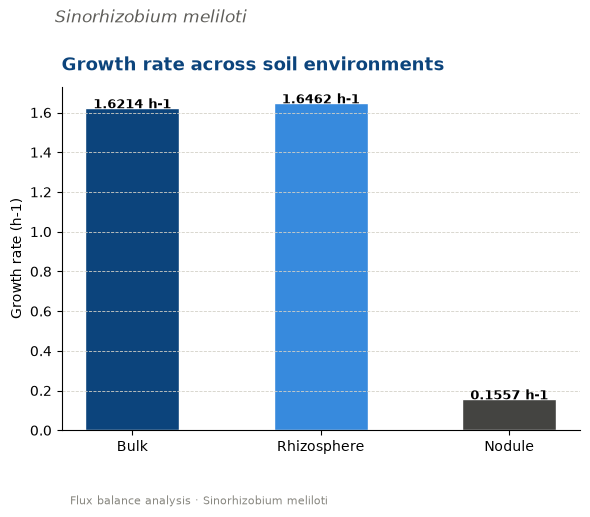

In [330]:
fig1, ax = plt.subplots(figsize=(6, 5))
mapping = {'Bulk': solution_bulk, 'Rhizosphere': solution_rh, 'Nodule': solution_no}
vals = [mapping[c].objective_value if getattr(mapping[c], "status", None) == "optimal" else 0 for c in conds]
bars = ax.bar(conds, vals, color=[COLORS[c] for c in conds], edgecolor="white", width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.0003, f"{v:.4f} h-1", ha="center", fontsize=9, fontweight="bold")
fig1.suptitle(species_name,
              fontsize=12, style="italic", color="#5F5E5A",
              x=0.1, y=0.95, ha="left")
ax.set_ylabel("Growth rate (h-1)")
ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
ax.set_title("Growth rate across soil environments",
             fontsize=13, fontweight="bold", color="#0C447C",
             loc="left", pad=12)
fig1.text(0.125, -0.04,
          f"Flux balance analysis · {species_name}",
          fontsize=8, color="#888780", ha="left")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig1.savefig(os.path.join(save_path, "1_growth_rate.png"), dpi=300)
plt.show()

plot 2 biomass over time 

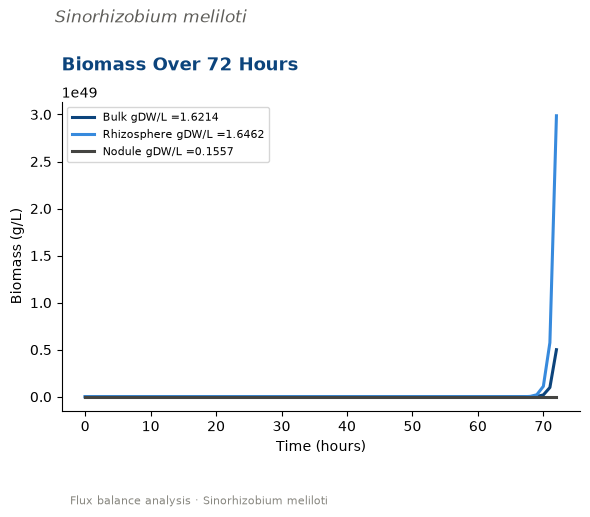

In [331]:
fig2, ax = plt.subplots(figsize=(6, 5))
for cond in conds:
    sub = time_df[time_df['Condition'] == cond].copy()
    sub = sub.rename(columns={'Time (hours)': 'time_h', 'Biomass (gDW/L)': 'biomass_gL'})
    sub['mu'] = mapping[cond].objective_value
    mu = sub["mu"].iloc[0]
    ax.plot(sub.time_h, sub.biomass_gL, color=COLORS[cond], linewidth=2.2, label=f"{cond} gDW/L ={mu:.4f}")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Biomass (g/L)")
ax.set_title("Biomass Over 72 Hours", fontsize=13, fontweight="bold", color="#0C447C",
             loc="left", pad=12)
fig2.text(0.125, -0.04,
          f"Flux balance analysis · {species_name}",
          fontsize=8, color="#888780", ha="left")
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)
fig2.suptitle(species_name,
              fontsize=12, style="italic", color="#5F5E5A",
              x=0.1, y=0.95, ha="left")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig2.savefig(os.path.join(save_path, "2_biomass_over_time.png"), dpi=300)
plt.show()

## PART 6 BIOMASS 
Biomass production rate is stepped from 0 to 90% of optimal.

biomass_id = "rxnBIOMASS"


In [332]:
solution = model.optimize()

In [333]:
f_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
solution = model.optimize()
growth_rate = solution.objective_value
biomass_value = []

for bio in f_values:
    model.reactions.get_by_id(biomass_id).lower_bound = bio*growth_rate
    solution = model.optimize()
    biomass_value.append({
        "Species": species_name,
        "Fraction": bio,
        "Biomass_rate_h-1": float(bio*growth_rate),
        "Max_growth_h-1": solution.objective_value
    })

# save 
df_biomass = pd.DataFrame(biomass_value)
df_biomass.to_csv(os.path.join(save_path,"biomass_value.csv"), index=False)

In [334]:
df_biomass

,Species,Fraction,Biomass_rate_h-1,Max_growth_h-1
0,Sinorhizobium meliloti,0.0,0.000000,89.912987
1,Sinorhizobium meliloti,0.1,8.991299,89.912987
2,Sinorhizobium meliloti,0.2,17.982597,89.912987
3,Sinorhizobium meliloti,0.3,26.973896,89.912987
4,Sinorhizobium meliloti,0.4,35.965195,89.912987
5,Sinorhizobium meliloti,0.5,44.956494,89.912987
6,Sinorhizobium meliloti,0.6,53.947792,89.912987
7,Sinorhizobium meliloti,0.7,62.939091,89.912987
8,Sinorhizobium meliloti,0.8,71.930390,89.912987
9,Sinorhizobium meliloti,0.9,80.921688,89.912987


Bulk soil environment analysis 

In [335]:
model_bulk.objective = biomass_id
solution_bulk = model_bulk.optimize()
max_growth_bulk = solution_bulk.objective_value

bulk_value = []
for bb in f_values:
    model_bulk.reactions.get_by_id(biomass_id).lower_bound = bb*max_growth_bulk
    bulk_value.append({
        "Species": species_name,
        "Environment": "Bulk soil",
        "Fraction": bb,
        "Biomass_rate_h-1": float(bb*max_growth_bulk),
        "Max_growth_h-1": solution_bulk.objective_value
    })

# save 
df_bulk = pd.DataFrame(bulk_value)
df_bulk.to_csv(os.path.join(save_path,"bulk_value.csv"), index=False)

In [336]:
print(df_bulk)

                  Species Environment  Fraction  Biomass_rate_h-1  \
0  Sinorhizobium meliloti   Bulk soil       0.0          0.000000   
1  Sinorhizobium meliloti   Bulk soil       0.1          0.162138   
2  Sinorhizobium meliloti   Bulk soil       0.2          0.324277   
3  Sinorhizobium meliloti   Bulk soil       0.3          0.486415   
4  Sinorhizobium meliloti   Bulk soil       0.4          0.648554   
5  Sinorhizobium meliloti   Bulk soil       0.5          0.810692   
6  Sinorhizobium meliloti   Bulk soil       0.6          0.972831   
7  Sinorhizobium meliloti   Bulk soil       0.7          1.134969   
8  Sinorhizobium meliloti   Bulk soil       0.8          1.297107   
9  Sinorhizobium meliloti   Bulk soil       0.9          1.459246   

   Max_growth_h-1  
0        1.621384  
1        1.621384  
2        1.621384  
3        1.621384  
4        1.621384  
5        1.621384  
6        1.621384  
7        1.621384  
8        1.621384  
9        1.621384  


Rhizosphere

In [337]:
model_rh.objective = biomass_id
max_growth_rh = model_rh.slim_optimize()

rh_value = []
for rh in f_values:
    model_rh.reactions.get_by_id(biomass_id).lower_bound = rh*max_growth_rh
    rh_value.append({
        "Species": species_name,
        "Environment": "Rhizosphere",
        "Fraction": rh,
        "Biomass_rate_h-1": float(rh*max_growth_rh),
        "Max_growth_h-1": solution_rh.objective_value
    })

# save 
df_rh = pd.DataFrame(rh_value)
df_rh.to_csv(os.path.join(save_path,"rhizosphere_value.csv"), index=False)

In [338]:
print(df_rh)

                  Species  Environment  Fraction  Biomass_rate_h-1  \
0  Sinorhizobium meliloti  Rhizosphere       0.0          0.000000   
1  Sinorhizobium meliloti  Rhizosphere       0.1          0.164619   
2  Sinorhizobium meliloti  Rhizosphere       0.2          0.329239   
3  Sinorhizobium meliloti  Rhizosphere       0.3          0.493858   
4  Sinorhizobium meliloti  Rhizosphere       0.4          0.658477   
5  Sinorhizobium meliloti  Rhizosphere       0.5          0.823097   
6  Sinorhizobium meliloti  Rhizosphere       0.6          0.987716   
7  Sinorhizobium meliloti  Rhizosphere       0.7          1.152335   
8  Sinorhizobium meliloti  Rhizosphere       0.8          1.316955   
9  Sinorhizobium meliloti  Rhizosphere       0.9          1.481574   

   Max_growth_h-1  
0        1.646193  
1        1.646193  
2        1.646193  
3        1.646193  
4        1.646193  
5        1.646193  
6        1.646193  
7        1.646193  
8        1.646193  
9        1.646193  


Nodule

In [339]:
model_no.objective = biomass_id
max_growth_no = model_no.slim_optimize()

no_value = []
for no in f_values:
    model_no.reactions.get_by_id(biomass_id).lower_bound = no*max_growth_no
    no_value.append({
        "Species": species_name,
        "Environment": "Nodule",
        "Fraction": no,
        "Biomass_rate_h-1": float(no*max_growth_no),
        "Max_growth_h-1": solution_no.objective_value
    })

# save 
df_no = pd.DataFrame(no_value)
df_no.to_csv(os.path.join(save_path,"nodule_value.csv"), index=False)

In [340]:
print(df_no)

                  Species Environment  Fraction  Biomass_rate_h-1  \
0  Sinorhizobium meliloti      Nodule       0.0          0.000000   
1  Sinorhizobium meliloti      Nodule       0.1          0.015568   
2  Sinorhizobium meliloti      Nodule       0.2          0.031135   
3  Sinorhizobium meliloti      Nodule       0.3          0.046703   
4  Sinorhizobium meliloti      Nodule       0.4          0.062271   
5  Sinorhizobium meliloti      Nodule       0.5          0.077838   
6  Sinorhizobium meliloti      Nodule       0.6          0.093406   
7  Sinorhizobium meliloti      Nodule       0.7          0.108974   
8  Sinorhizobium meliloti      Nodule       0.8          0.124542   
9  Sinorhizobium meliloti      Nodule       0.9          0.140109   

   Max_growth_h-1  
0        0.155677  
1        0.155677  
2        0.155677  
3        0.155677  
4        0.155677  
5        0.155677  
6        0.155677  
7        0.155677  
8        0.155677  
9        0.155677  


In [341]:
biomass = []
for df in [df_bulk, df_rh, df_no]:
    biomass.append(df)

biomass_df = pd.concat(biomass, ignore_index=True)
biomass_df.to_csv(os.path.join(save_path,f"{species_name}_biomass_all_env.csv"), index=False)

In [342]:
biomass_df

,Species,Environment,Fraction,Biomass_rate_h-1,Max_growth_h-1
0,Sinorhizobium meliloti,Bulk soil,0.0,0.000000,1.621384
1,Sinorhizobium meliloti,Bulk soil,0.1,0.162138,1.621384
2,Sinorhizobium meliloti,Bulk soil,0.2,0.324277,1.621384
3,Sinorhizobium meliloti,Bulk soil,0.3,0.486415,1.621384
4,Sinorhizobium meliloti,Bulk soil,0.4,0.648554,1.621384
5,Sinorhizobium meliloti,Bulk soil,0.5,0.810692,1.621384
6,Sinorhizobium meliloti,Bulk soil,0.6,0.972831,1.621384
7,Sinorhizobium meliloti,Bulk soil,0.7,1.134969,1.621384
8,Sinorhizobium meliloti,Bulk soil,0.8,1.297107,1.621384
9,Sinorhizobium meliloti,Bulk soil,0.9,1.459246,1.621384


## PART 7 NITROGEN FIXATION
STEP 1: CAN THE MODEL FIXED NITROGEN?

EX_cpdFixed_e0,Fixed ammonia e0,-1000.0,1000.0

In [343]:
# set the objective function to EX_cpdFixed_e0 (Fixed ammonia)
model.objective = NH3_id

# run FBA 
model.optimize()
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
cpd00007[e0],EX_cpd00007_e0,135.9,0,0.00%
cpd00009[e0],EX_cpd00009_e0,2.046,0,0.00%
cpd00030[e0],EX_cpd00030_e0,0.0008092,0,0.00%
cpd00034[e0],EX_cpd00034_e0,0.0008092,0,0.00%
cpd00039[e0],EX_cpd00039_e0,14.3,6,0.48%
cpd00051[e0],EX_cpd00051_e0,272.6,6,9.11%
cpd00060[e0],EX_cpd00060_e0,10.85,5,0.30%
cpd00063[e0],EX_cpd00063_e0,0.0008092,0,0.00%
cpd00067[e0],EX_cpd00067_e0,1000,0,0.00%
cpd00069[e0],EX_cpd00069_e0,10.22,9,0.51%


STEP 2: CAN EACH ENVIRONMENT CAN DO THE NITROGEN FIXATION

It have to change the environment medium into open for nitrogen form that plant can usage and close for all nitrogen to force bacteria to fix nitrogen 

In [344]:
model = read_sbml_model(sbml_fname)
def apply_medium(model_obj, medium):
    # reset exchange lower bounds then apply provided medium bounds
    for r in model_obj.exchanges:
        r.lower_bound = 0
    for comp_id, bound in medium.items():
        if comp_id in model_obj.reactions:
            model_obj.reactions.get_by_id(comp_id).lower_bound = bound
        else:
            print(f"WARNING: {comp_id} not found in model {model_obj.id}")


# model_bulk
model_bulk = model.copy()
model_bulk.objective = biomass_reaction
apply_medium(model_bulk, bulk_medium)

# model_rh
model_rh = model.copy()
model_rh.objective = biomass_reaction
apply_medium(model_rh, rh_medium)

# model_no
model_no = model.copy()
model_no.objective = biomass_reaction
apply_medium(model_no, nodule_medium)


Bulk soil

In [345]:
# set the objective function to EX_cpdFixed_e0 (Fixed NH4)
model_bulk.objective = NH3_id
# run FBA
model_bulk.optimize() 
model_bulk.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
Metabolite,Reaction,Flux,C-Number,C-Flux


Rhizoshere

In [346]:
model_rh.objective = NH3_id
# run 
model_rh.optimize()
model_rh.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
cpd00007[e0],EX_cpd00007_e0,13.04,0,0.00%
cpd00009[e0],EX_cpd00009_e0,0.1416,0,0.00%
cpd00013[e0],EX_cpd00013_e0,7.5,0,0.00%
cpd00023[e0],EX_cpd00023_e0,0.02833,5,0.09%
cpd00027[e0],EX_cpd00027_e0,0.04098,6,0.15%
cpd00035[e0],EX_cpd00035_e0,0.00823,3,0.02%
cpd00036[e0],EX_cpd00036_e0,0.1224,4,0.30%
cpd00041[e0],EX_cpd00041_e0,0.03206,4,0.08%
cpd00048[e0],EX_cpd00048_e0,0.2125,0,0.00%
cpd00051[e0],EX_cpd00051_e0,0.009487,6,0.04%


In [347]:
model_rh

Name,iGD1348
Memory address,152c9e9f650
Number of metabolites,1160
Number of reactions,1407
Number of genes,1351
Number of groups,0
Objective expression,1.0*EX_cpdFixed_e0 - 1.0*EX_cpdFixed_e0_reverse_a4ffb
Compartments,"Cytoplasm, Extracellular"


Nodule

In [348]:
model_no.objective = NH3_id
model_no.optimize()
model_no.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
cpd00007[e0],EX_cpd00007_e0,1.26,0,0.00%
cpd00009[e0],EX_cpd00009_e0,0.01319,0,0.00%
cpd00023[e0],EX_cpd00023_e0,2,5,53.22%
cpd00036[e0],EX_cpd00036_e0,1.055,4,22.46%
cpd00048[e0],EX_cpd00048_e0,0.01979,0,0.00%
cpd00067[e0],EX_cpd00067_e0,8.249,0,0.00%
cpd00121[e0],EX_cpd00121_e0,0.01,6,0.32%
cpd00130[e0],EX_cpd00130_e0,1.112,4,23.67%
cpd00149[e0],EX_cpd00149_e0,0.003298,0,0.00%
cpd00254[e0],EX_cpd00254_e0,0.003298,0,0.00%


In [349]:
# save nitrogen
with open(os.path.join(save_path, "N2_results.txt"), "w") as f:
    solution_bulk = model_bulk.optimize()
    solution_rh = model_rh.optimize()
    solution_no = model_no.optimize()

    with open(os.path.join(save_path, "N2_results.txt"), "w") as f:
        f.write(f"Status: \nBulk: {solution_bulk.status}, Rhizosphere: {solution_rh.status}, Nodule: {solution_no.status}\n")
        f.write(f"Fixed nitrogen: \nBulk: {solution_bulk.objective_value}, Rhizosphere: {solution_rh.objective_value}, Nodule: {solution_no.objective_value}\n")


Fixed nitrogen over time 72 hours

In [350]:
# Recreate nitrogen over time correctly and print values at selected times
X0 = 0.01
t_hours = np.arange(0, 73, 1)
time_rows = []
for cond_name, model_obj in zip(['Bulk', 'Rhizosphere', 'Nodule'], [model_bulk, model_rh, model_no]):
    sol = model_obj.optimize()
    mu = sol.objective_value
    X_t = X0 * np.exp(mu * t_hours)
    for t, nitrogen in zip(t_hours, X_t):
        time_rows.append({
            "Condition": cond_name,
            "Time (hours)": int(t),
            "Nitrogen (gDW/L)": float(nitrogen)
        })

nitrogen_df = pd.DataFrame(time_rows)
nitrogen_df.to_csv(os.path.join(save_path, f"fix_N2_over_time_{model.name}.csv"), sep="\t", index=False)
print(f"Successfully saved nitrogen over time data to {save_path}/fix_N2_over_time_{model.name}.csv")

# show nitrogen at selected times
for cond in ['Bulk', 'Rhizosphere', 'Nodule']:
    sub = nitrogen_df[nitrogen_df['Condition'] == cond]
    for t in [0, 12, 24, 48, 72]:
        rows = sub[sub['Time (hours)'] == t]
        if rows.empty:
            print(f"{cond} t={t}: no data")
        else:
            n = rows['Nitrogen (gDW/L)'].iloc[0]
            print(f"{cond} t={t}: {n:.4f} gDW/L")

Successfully saved nitrogen over time data to Results_S_meliloti_1348/fix_N2_over_time_Sinorhizobium_meliloti_1021.csv
Bulk t=0: 0.0100 gDW/L
Bulk t=12: 0.0100 gDW/L
Bulk t=24: 0.0100 gDW/L
Bulk t=48: 0.0100 gDW/L
Bulk t=72: 0.0100 gDW/L
Rhizosphere t=0: 0.0100 gDW/L
Rhizosphere t=12: 28420938478081392.0000 gDW/L
Rhizosphere t=24: 80774974397488738634606553000312832.0000 gDW/L
Rhizosphere t=48: 652459648891496115056764932275592671447392283057437514733946206070767616.0000 gDW/L
Rhizosphere t=72: 5270241143460585187773351995677079072939153714252442695591211641909119910566832077169944763330869343023005696.0000 gDW/L
Nodule t=0: 0.0100 gDW/L
Nodule t=12: 0.5230 gDW/L
Nodule t=24: 27.3581 gDW/L
Nodule t=48: 74846.4258 gDW/L
Nodule t=72: 204765411.6942 gDW/L


plot 4: fixed nitrogen in each environment

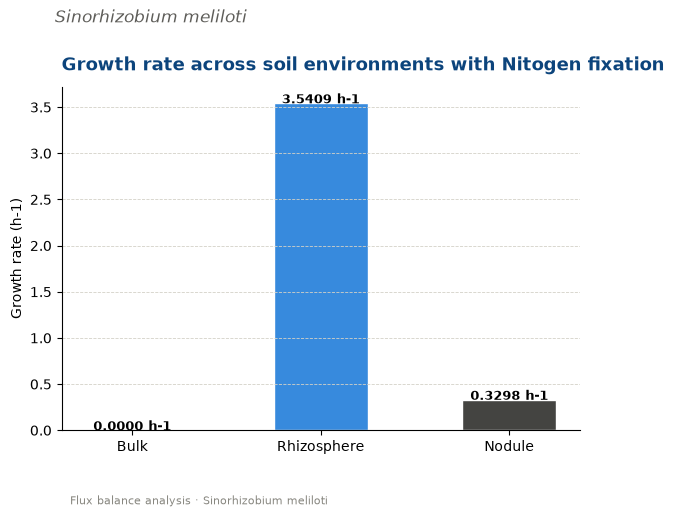

In [351]:
# N2 fixation rate
fig4, ax = plt.subplots(figsize=(6, 5))
mapping = {'Bulk': solution_bulk, 'Rhizosphere': solution_rh, 'Nodule': solution_no}
vals = [mapping[c].objective_value if getattr(mapping[c], "status", None) == "optimal" else 0 for c in conds]
bars = ax.bar(conds, vals, color=[COLORS[c] for c in conds], edgecolor="white", width=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.0003, f"{v:.4f} h-1", ha="center", fontsize=9, fontweight="bold")
fig4.suptitle(species_name,
              fontsize=12, style="italic", color="#5F5E5A",
              x=0.1, y=0.95, ha="left")
ax.set_ylabel("Growth rate (h-1)")  
ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
ax.set_title("Growth rate across soil environments with Nitogen fixation",
                fontsize=13, fontweight="bold", color="#0C447C",
                loc="left", pad=12)
fig4.text(0.125, -0.04,
          f"Flux balance analysis · {species_name}",
          fontsize=8, color="#888780", ha="left")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig4.savefig(os.path.join(save_path, "4_growth_rate_with_N2_fixation.png"), dpi=300)
plt.show()

plot 5: Fixed nitrogen over time

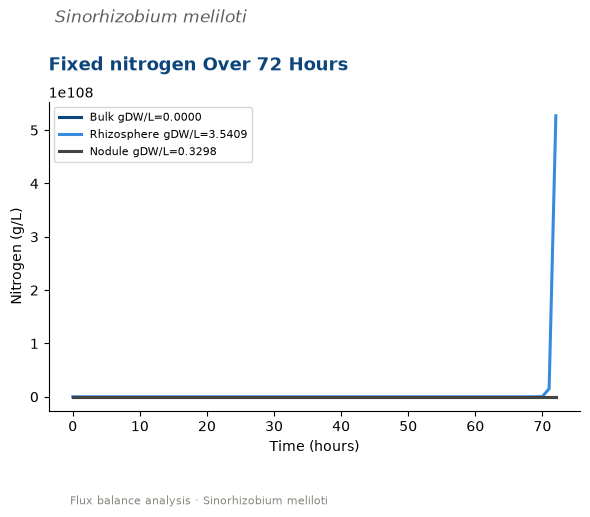

In [352]:
fig5, ax = plt.subplots(figsize=(6, 5))
for cond in conds:
    sub = nitrogen_df[nitrogen_df['Condition'] == cond].copy()
    sub = sub.rename(columns={'Time (hours)': 'time_h', 'Nitrogen (gDW/L)': 'nitrogen_gL'})
    mu = mapping[cond].objective_value
    ax.plot(sub.time_h, sub.nitrogen_gL, color=COLORS[cond], linewidth=2.2, label=f"{cond} gDW/L={mu:.4f}")
ax.set_xlabel("Time (hours)")
ax.set_ylabel("Nitrogen (g/L)")
ax.set_title("Fixed nitrogen Over 72 Hours", fontsize=13, fontweight="bold", color="#0C447C",
             loc="left", pad=12)
fig5.text(0.125, -0.04,
          f"Flux balance analysis · {species_name}",
          fontsize=8, color="#888780", ha="left")
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)
fig5.suptitle(species_name,
              fontsize=12, style="italic", color="#5F5E5A",
              x=0.1, y=0.95, ha="left")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig5.savefig(os.path.join(save_path, "5_N2_over_time.png"), dpi=300)
plt.show()

## PART 8: NITROGEN FIXATION
Maximum nitrogen fixation flux is recorded at each step from 0 to 90% of optimal.

This is done for each environment (Bluk soil, Rhizosphere, and Nodule) and for a nitrogen fixation.


NH3_id = "EX_cpdFixed_e0"

In [353]:
model.objective = NH3_id
solution = model.optimize()

n2_value = []

for n2 in f_values:
    model.reactions.get_by_id(biomass_id).lower_bound = n2*growth_rate
    solution = model.optimize()
    n2_value.append({
        "Species": species_name,
        "Fraction": n2,
        "Growth_rate": float(n2*growth_rate),
        "N2_rate_mmol_gDW_h": solution.objective_value
        
    })

# save 
df_n2 = pd.DataFrame(n2_value)
df_n2.to_csv(os.path.join(save_path,"n2_value.csv"), index=False)



In [354]:
print(df_n2)

                  Species  Fraction  Growth_rate  N2_rate_mmol_gDW_h
0  Sinorhizobium meliloti       0.0     0.000000          142.857143
1  Sinorhizobium meliloti       0.1     8.991299          138.339377
2  Sinorhizobium meliloti       0.2    17.982597          133.821612
3  Sinorhizobium meliloti       0.3    26.973896          129.303846
4  Sinorhizobium meliloti       0.4    35.965195          124.786080
5  Sinorhizobium meliloti       0.5    44.956494          120.268315
6  Sinorhizobium meliloti       0.6    53.947792          115.750549
7  Sinorhizobium meliloti       0.7    62.939091          111.232784
8  Sinorhizobium meliloti       0.8    71.930390          106.715018
9  Sinorhizobium meliloti       0.9    80.921688          102.197252


Analyse biomass for each environment 

Bulk soil

In [355]:
model_bulk.objective = NH3_id
solution_bulk = model_bulk.optimize()

bulk_n2 = []
for bb in f_values:
    model_bulk.reactions.get_by_id(biomass_id).lower_bound = bb*max_growth_bulk
    solution_bulk = model_bulk.optimize()
    bulk_n2.append({
        "Species": species_name,
        "Environment": "Bulk soil",
        "Fraction": bb,
        "Growth_rate":  float(bb*max_growth_bulk),
        "N2_rate_mmol_gDW_h":  solution_bulk.objective_value
    })

# save 
df_bulk_n2 = pd.DataFrame(bulk_n2)
df_bulk_n2.to_csv(os.path.join(save_path,"bulk_n2.csv"), index=False)

In [356]:
print(df_bulk_n2)

                  Species Environment  Fraction  Growth_rate  \
0  Sinorhizobium meliloti   Bulk soil       0.0     0.000000   
1  Sinorhizobium meliloti   Bulk soil       0.1     0.162138   
2  Sinorhizobium meliloti   Bulk soil       0.2     0.324277   
3  Sinorhizobium meliloti   Bulk soil       0.3     0.486415   
4  Sinorhizobium meliloti   Bulk soil       0.4     0.648554   
5  Sinorhizobium meliloti   Bulk soil       0.5     0.810692   
6  Sinorhizobium meliloti   Bulk soil       0.6     0.972831   
7  Sinorhizobium meliloti   Bulk soil       0.7     1.134969   
8  Sinorhizobium meliloti   Bulk soil       0.8     1.297107   
9  Sinorhizobium meliloti   Bulk soil       0.9     1.459246   

   N2_rate_mmol_gDW_h  
0                 0.0  
1                 0.0  
2                 0.0  
3                 0.0  
4                 0.0  
5                 0.0  
6                 0.0  
7                 0.0  
8                 0.0  
9                 0.0  


Rhizosphere

In [357]:
model_rh.objective = NH3_id
solution_rh = model_rh.optimize()

rh_n2 = []
for rh in f_values:
    model_rh.reactions.get_by_id(biomass_id).lower_bound = rh*max_growth_rh
    solution_rh = model_rh.optimize()
    rh_n2.append({
        "Species": species_name,
        "Environment": "Rhizosphere",
        "Fraction": rh,
        "Growth_rate":  float(rh*max_growth_rh),
        "N2_rate_mmol_gDW_h":  solution_rh.objective_value
    })

# save 
df_rh_n2 = pd.DataFrame(rh_n2)
df_rh_n2.to_csv(os.path.join(save_path,"rhizosphere_n2.csv"), index=False)

In [358]:
print(df_rh_n2)

                  Species  Environment  Fraction  Growth_rate  \
0  Sinorhizobium meliloti  Rhizosphere       0.0     0.000000   
1  Sinorhizobium meliloti  Rhizosphere       0.1     0.164619   
2  Sinorhizobium meliloti  Rhizosphere       0.2     0.329239   
3  Sinorhizobium meliloti  Rhizosphere       0.3     0.493858   
4  Sinorhizobium meliloti  Rhizosphere       0.4     0.658477   
5  Sinorhizobium meliloti  Rhizosphere       0.5     0.823097   
6  Sinorhizobium meliloti  Rhizosphere       0.6     0.987716   
7  Sinorhizobium meliloti  Rhizosphere       0.7     1.152335   
8  Sinorhizobium meliloti  Rhizosphere       0.8     1.316955   
9  Sinorhizobium meliloti  Rhizosphere       0.9     1.481574   

   N2_rate_mmol_gDW_h  
0            3.540923  
1            3.186830  
2            2.832738  
3            2.478646  
4            2.124554  
5            1.770461  
6            1.416369  
7            1.062277  
8            0.708185  
9            0.354092  


Nodule

In [359]:
model_no.objective = NH3_id
solution_no = model_no.optimize()

no_n2 = []
for no in f_values:
    model_no.reactions.get_by_id(biomass_id).lower_bound = no*max_growth_no
    solution_no = model_no.optimize()
    no_n2.append({
        "Species": species_name,
        "Environment": "Nodule",
        "Fraction": no,
        "Growth_rate":  float(no*max_growth_no),
        "N2_rate_mmol_gDW_h":  solution_no.objective_value
    })

# save 
df_no_n2 = pd.DataFrame(no_n2)
df_no_n2.to_csv(os.path.join(save_path,"nodule_n2.csv"), index=False)

In [360]:
print(df_no_n2)

                  Species Environment  Fraction  Growth_rate  \
0  Sinorhizobium meliloti      Nodule       0.0     0.000000   
1  Sinorhizobium meliloti      Nodule       0.1     0.015568   
2  Sinorhizobium meliloti      Nodule       0.2     0.031135   
3  Sinorhizobium meliloti      Nodule       0.3     0.046703   
4  Sinorhizobium meliloti      Nodule       0.4     0.062271   
5  Sinorhizobium meliloti      Nodule       0.5     0.077838   
6  Sinorhizobium meliloti      Nodule       0.6     0.093406   
7  Sinorhizobium meliloti      Nodule       0.7     0.108974   
8  Sinorhizobium meliloti      Nodule       0.8     0.124542   
9  Sinorhizobium meliloti      Nodule       0.9     0.140109   

   N2_rate_mmol_gDW_h  
0            0.329758  
1            0.300355  
2            0.270952  
3            0.240125  
4            0.209035  
5            0.177945  
6            0.146826  
7            0.110119  
8            0.073413  
9            0.036706  


In [361]:
n2 = []
for df_n2 in [df_bulk_n2, df_rh_n2, df_no_n2]:
    n2.append(df_n2)

n2_df = pd.concat(n2, ignore_index=True)
n2_df.to_csv(os.path.join(save_path,f"{species_name}_n2_all_env.csv"), index=False)

In [362]:
n2_df

,Species,Environment,Fraction,Growth_rate,N2_rate_mmol_gDW_h
0,Sinorhizobium meliloti,Bulk soil,0.0,0.000000,0.000000
1,Sinorhizobium meliloti,Bulk soil,0.1,0.162138,0.000000
2,Sinorhizobium meliloti,Bulk soil,0.2,0.324277,0.000000
3,Sinorhizobium meliloti,Bulk soil,0.3,0.486415,0.000000
4,Sinorhizobium meliloti,Bulk soil,0.4,0.648554,0.000000
5,Sinorhizobium meliloti,Bulk soil,0.5,0.810692,0.000000
6,Sinorhizobium meliloti,Bulk soil,0.6,0.972831,0.000000
7,Sinorhizobium meliloti,Bulk soil,0.7,1.134969,0.000000
8,Sinorhizobium meliloti,Bulk soil,0.8,1.297107,0.000000
9,Sinorhizobium meliloti,Bulk soil,0.9,1.459246,0.000000


## PART 9: VISUALISATION

Combine dataframe

In [363]:
environments = [('Bulk', df_bulk, '#1f77b4'), ('Rhizosphere', df_rh, '#ff7f0e'), ('Nodule', df_no, '#2ca02c')]

Biomass growth rate 

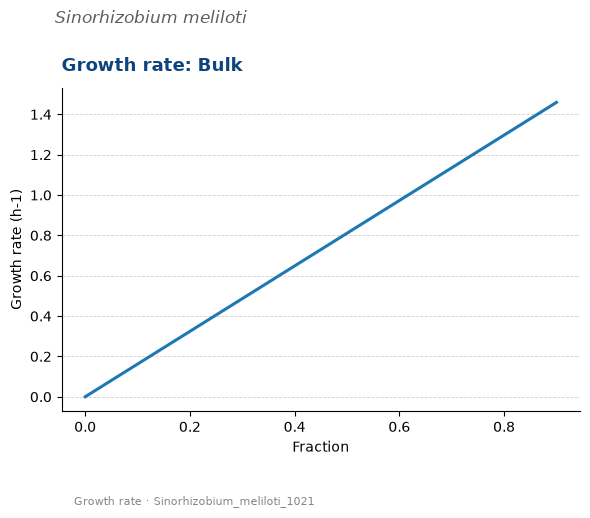

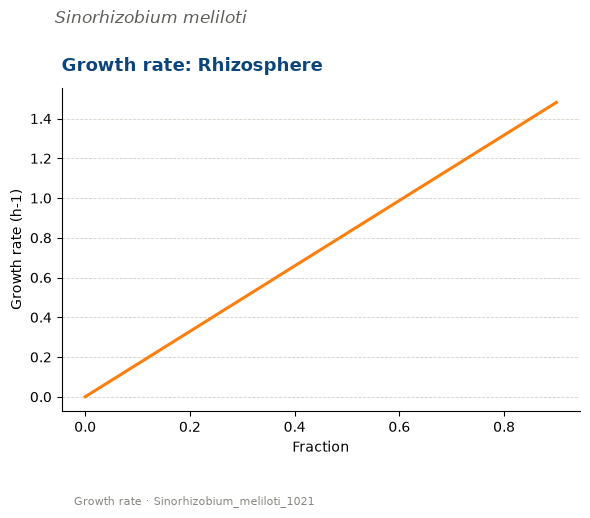

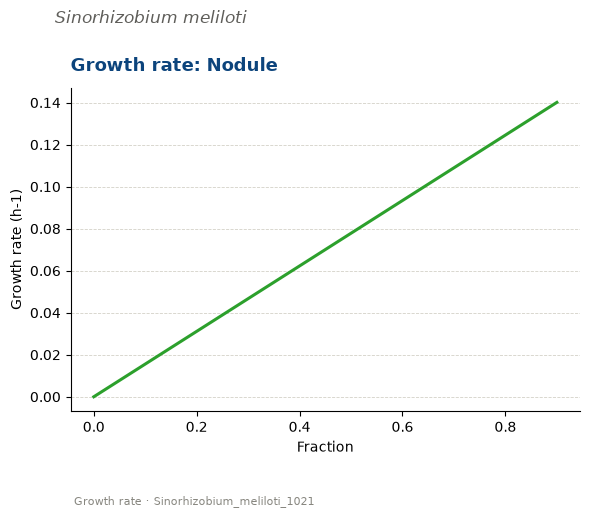

In [364]:
for name, df, color in environments:
    fig6, ax = plt.subplots(figsize=(6, 5))
    ax.plot(df['Fraction'], df['Biomass_rate_h-1'], color=color, linewidth=2.2)
    
    ax.set_ylabel("Growth rate (h-1)")
    ax.set_xlabel("Fraction")
    ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
    ax.set_title(f"Growth rate: {name}", fontsize=13, fontweight="bold", color="#0C447C", loc="left", pad=12)
    
    fig6.suptitle(species_name, fontsize=12, style="italic", color="#5F5E5A", x=0.1, y=0.95, ha="left")
    fig6.text(0.125, -0.04, f" Growth rate · {model.name}", fontsize=8, color="#888780", ha="left")
    ax.spines[["top","right"]].set_visible(False)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig6.savefig(os.path.join(save_path, f"6_growth_{name}.png"), dpi=300)

Nitrogen

In [365]:
environments = [('Bulk', df_bulk_n2, '#1f77b4'), ('Rhizosphere', df_rh_n2, '#ff7f0e'), ('Nodule', df_no_n2, '#2ca02c')]

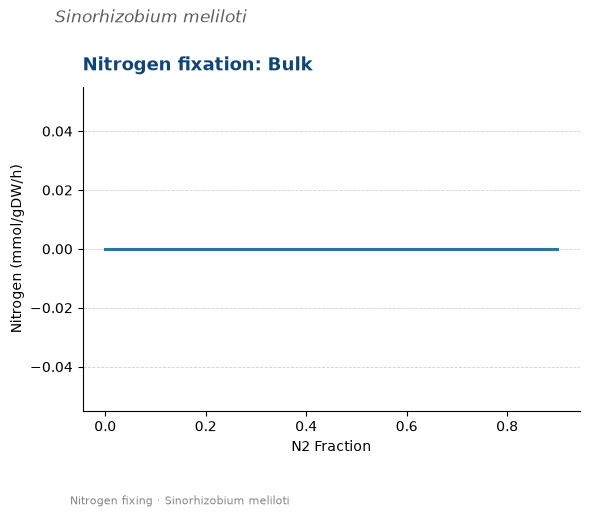

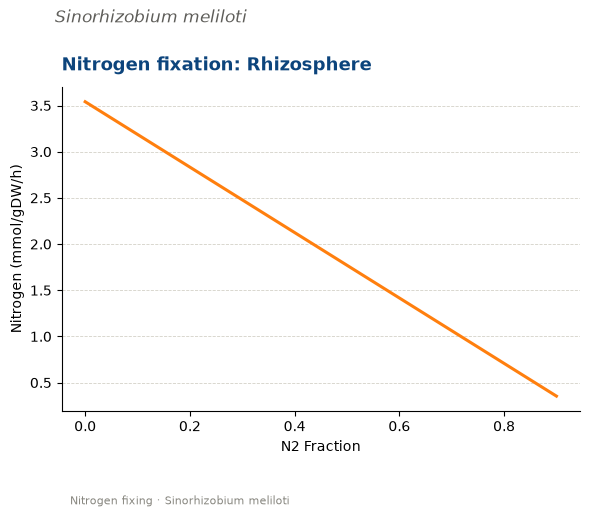

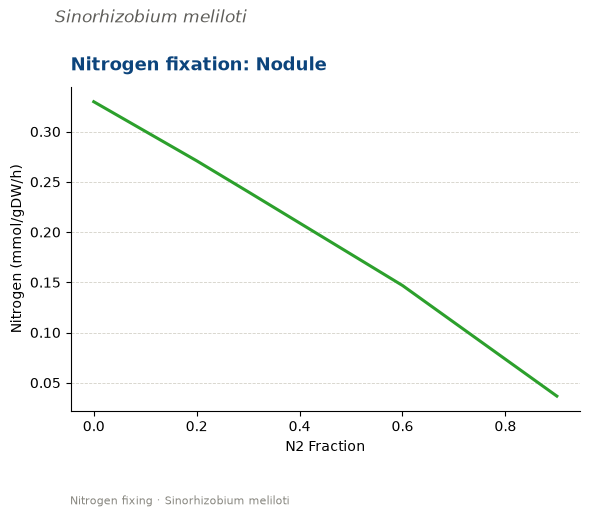

In [366]:
for name, df, color in environments:
    fig7, ax = plt.subplots(figsize=(6, 5))
    ax.plot(df['Fraction'], df['N2_rate_mmol_gDW_h'], color=color, linewidth=2.2)
    
    ax.set_ylabel("Nitrogen (mmol/gDW/h)")
    ax.set_xlabel("N2 Fraction")
    ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
    ax.set_title(f"Nitrogen fixation: {name}", fontsize=13, fontweight="bold", color="#0C447C", loc="left", pad=12)
    
    fig7.suptitle(species_name, fontsize=12, style="italic", color="#5F5E5A", x=0.1, y=0.95, ha="left")
    fig7.text(0.125, -0.04, f"Nitrogen fixing · {species_name}", fontsize=8, color="#888780", ha="left")
    ax.spines[["top","right"]].set_visible(False)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    fig7.savefig(os.path.join(save_path, f"7_n2_{name}.png"), dpi=300)


Combine biomass

In [367]:
environments = [('Bulk', df_bulk, '#1f77b4'), ('Rhizosphere', df_rh, '#ff7f0e'), ('Nodule', df_no, '#2ca02c')]

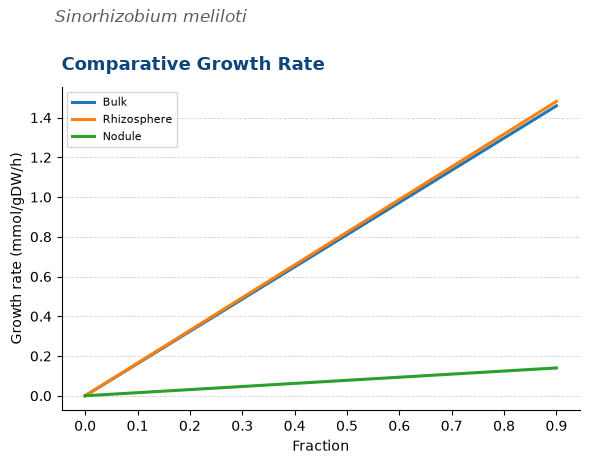

In [368]:
fig8, ax = plt.subplots(figsize=(6, 5))
for name, df, color in environments:
    ax.plot(df['Fraction'], df['Biomass_rate_h-1'], label=name, color=color, linewidth=2.2)

ax.set_ylabel("Growth rate (mmol/gDW/h)")
ax.set_xlabel("Fraction")
ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
ax.set_title("Comparative Growth Rate", fontsize=13, fontweight="bold", color="#0C447C", loc="left", pad=12)
fig8.suptitle(species_name, fontsize=12, style="italic", color="#5F5E5A", x=0.1, y=0.95, ha="left")
#fig8.text(0.125, -0.04, f" · {species_name}", fontsize=8, color="#888780", ha="left")
ax.spines[["top","right"]].set_visible(False)
ax.legend(fontsize=8)
x = f_values
plt.xticks(x)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig8.savefig(os.path.join(save_path, "8_combined_biomass.png"), dpi=300)
plt.show()

Combine nitrogen

In [369]:
environments = [('Bulk', df_bulk_n2, '#1f77b4'), ('Rhizosphere', df_rh_n2, '#ff7f0e'), ('Nodule', df_no_n2, '#2ca02c')]

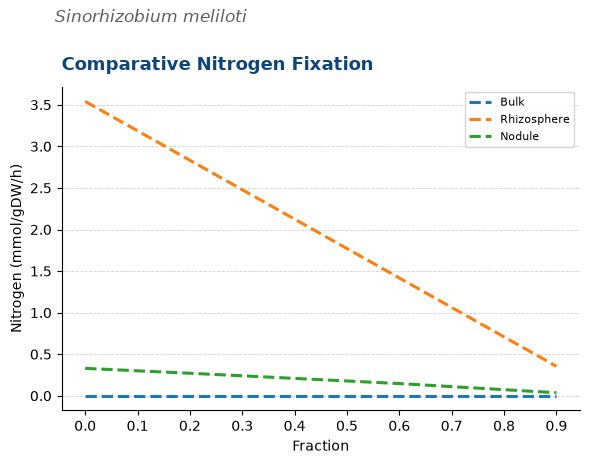

In [370]:
fig9, ax = plt.subplots(figsize=(6, 5))
for name, df, color in environments:
    ax.plot(df['Fraction'], df['N2_rate_mmol_gDW_h'], label=name, color=color, linewidth=2.2, linestyle="--")

ax.set_ylabel("Nitrogen (mmol/gDW/h)")
ax.set_xlabel("Fraction")
ax.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
ax.set_title("Comparative Nitrogen Fixation", fontsize=13, fontweight="bold", color="#0C447C", loc="left", pad=12)
fig9.suptitle(species_name, fontsize=12, style="italic", color="#5F5E5A", x=0.1, y=0.95, ha="left")
#fig9.text(0.125, -0.04, f" · {species_name}", fontsize=8, color="#888780", ha="left")
ax.spines[["top","right"]].set_visible(False)
ax.legend(fontsize=8)
x = f_values
plt.xticks(x)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig9.savefig(os.path.join(save_path, "9_combined_n2.png"), dpi=300)
plt.show()

Combine biomass and nitrogen

In [371]:
environments = {
    "Bulk": df_bulk_n2,
    "Rhizosphere": df_rh_n2,
    "Nodule": df_no_n2
}

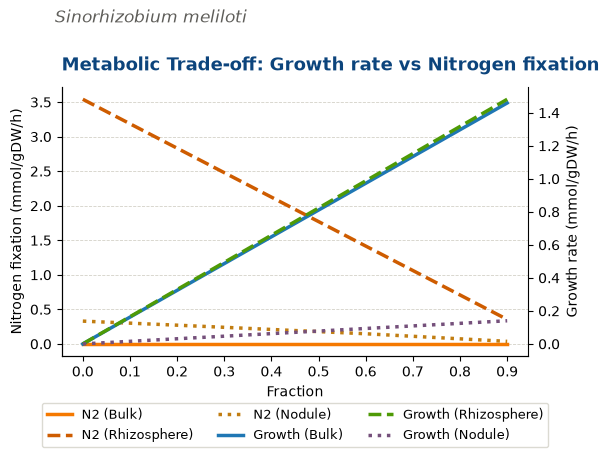

In [372]:
growth_colors = {'Bulk': '#1f77b4', 'Rhizosphere': '#4e9a06', 'Nodule': '#75507b'}
n2_colors = {'Bulk': '#f57900', 'Rhizosphere': '#ce5c00', 'Nodule': '#c17d11'}

linestyles = {'Bulk': '-', 'Rhizosphere': '--', 'Nodule': ':'}

fig10, ax1 = plt.subplots(figsize=(6, 5))
ax2 = ax1.twinx()

for name, df in environments.items():
    # Plot Nitrogen
    ax1.plot(df['Fraction'], df['N2_rate_mmol_gDW_h'], 
             color=n2_colors[name], 
             linestyle=linestyles[name], 
             linewidth=2.5, 
             label=f'N2 ({name})')
    # Plot Biomass (Growth)
    ax2.plot(df['Fraction'], df['Growth_rate'], 
             color=growth_colors[name], 
             linestyle=linestyles[name], 
             linewidth=2.5, 
             label=f'Growth ({name})')
    
    

ax1.set_xlabel("Fraction")
ax2.set_ylabel("Growth rate (mmol/gDW/h)") 
ax1.set_ylabel("Nitrogen fixation (mmol/gDW/h)")
ax1.yaxis.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
ax2.set_title("Metabolic Trade-off: Growth rate vs Nitrogen fixation", fontsize=13, fontweight="bold", color="#0C447C", loc="left", pad=12)
fig10.suptitle(species_name, fontsize=12, style="italic", color="#5F5E5A", x=0.1, y=0.95, ha="left")
#fig10.text(0.125, 0, f" · {species_name}", fontsize=8, color="#888780", ha="left")
ax2.spines[["top", "right"]].set_visible(False)
ax1.spines[["top"]].set_visible(False)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, 
           labels1 + labels2, 
           loc='upper center', 
           bbox_to_anchor=(0.5, -0.15), 
           ncol=3, 
           frameon=True, 
           fontsize=9, 
           edgecolor='#D3D1C7')
x = f_values
plt.xticks(x)
plt.tight_layout(rect=[0, 0.01, 1, 0.95])
fig10.savefig(os.path.join(save_path, "10_integrated_tradeoff.png"), dpi=300)
plt.show()

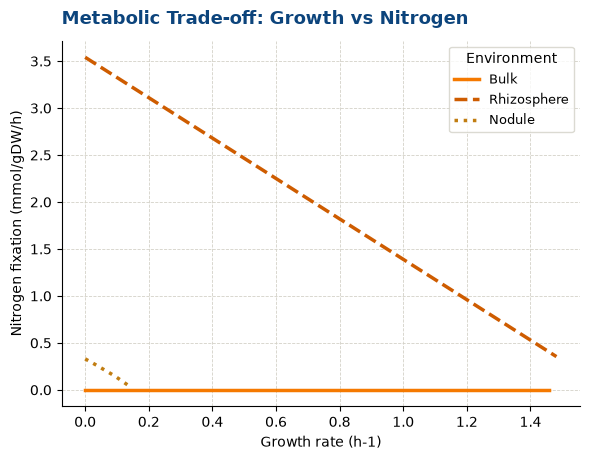

In [373]:
fig11, ax = plt.subplots(figsize=(6, 5))

for name, df in environments.items():
    ax.plot(df['Growth_rate'], 
            df['N2_rate_mmol_gDW_h'], 
            color=n2_colors[name], 
            linestyle=linestyles[name], 
            linewidth=2.5, 
            label=f'{name}')

ax.set_xlabel("Growth rate (h-1)")
ax.set_ylabel("Nitrogen fixation (mmol/gDW/h)")
ax.grid(True, color="#D3D1C7", linewidth=0.6, linestyle="--")
ax.set_title("Metabolic Trade-off: Growth vs Nitrogen", fontsize=13, fontweight="bold", color="#0C447C", loc="left", pad=12)
fig10.suptitle(species_name, fontsize=12, style="italic", color="#5F5E5A", x=0.1, y=0.95, ha="left")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc='upper right', frameon=True, fontsize=9, edgecolor='#D3D1C7', title="Environment")

plt.tight_layout(rect=[0, 0.01, 1, 0.95])
fig10.savefig(os.path.join(save_path, "11_growth_n2_tradeoff.png"), dpi=300)
plt.show()